In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
steam = pd.read_csv("../Data/Cleaned/steam.csv")

### Genre Analysis - Question 1

In [4]:
steam["Genres"].value_counts()

Genres
Casual,Indie                                                 6912
Action,Indie                                                 5802
Action,Adventure,Indie                                       5259
Adventure,Indie                                              4422
Adventure,Casual,Indie                                       3691
                                                             ... 
Adventure,Simulation,Sports,Early Access                        1
Action,Indie,RPG,Simulation,Strategy,Free To Play               1
Action,Adventure,Casual,Racing,RPG,Sports                       1
Action,Casual,RPG,Simulation,Sports,Strategy,Early Access       1
Action,Simulation,Strategy,Free To Play,Early Access            1
Name: count, Length: 2922, dtype: int64

In [5]:
genres = steam.copy()

In [6]:
genres["Genres"] = genres["Genres"].str.split(",")

In [7]:
genres = genres.explode("Genres")

In [8]:
genre_counts = (
    genres["Genres"]
    .value_counts()
    .head(15)
)

genre_counts

Genres
Indie                    82884
Casual                   51671
Action                   47344
Adventure                46293
Simulation               24911
Strategy                 23058
RPG                      21577
Free To Play             12605
Early Access             11572
Sports                    4970
Racing                    4169
Massively Multiplayer     2596
Utilities                 1091
Design & Illustration      584
Animation & Modeling       484
Name: count, dtype: int64

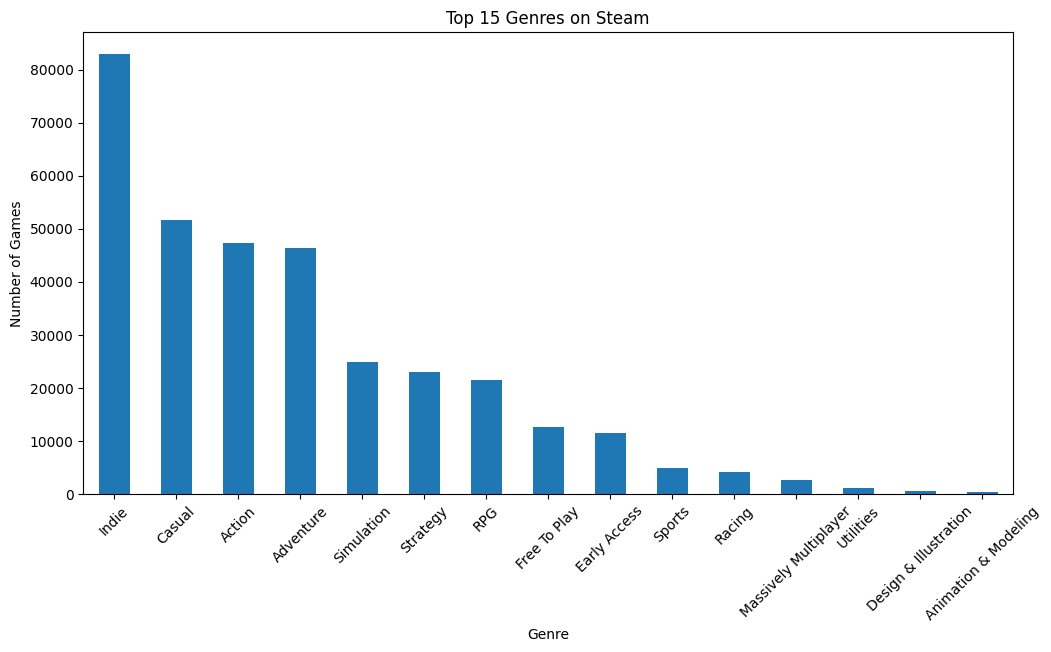

In [9]:
plt.figure(figsize=(12,6))

genre_counts.plot(kind="bar")

plt.title("Top 15 Genres on Steam")
plt.xlabel("Genre")
plt.ylabel("Number of Games")

plt.xticks(rotation=45)

plt.savefig("../Images/Genre Analysis/top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

### Genre Analysis - Question 2

In [10]:
genres["Genres"] = genres["Genres"].str.strip()

In [11]:
genres = genres[
    (genres["Total Reviews"] > 0) &
    (genres["Genres"].notna())
]

In [12]:
genre_reviews = (
    genres
    .groupby("Genres")["Review Score %"]
    .mean()
    .sort_values(ascending=False)
)

In [13]:
genre_counts = genres["Genres"].value_counts()

valid_genres = genre_counts[genre_counts >= 100].index

In [14]:
genre_reviews = (
    genres[genres["Genres"].isin(valid_genres)]
    .groupby("Genres")["Review Score %"]
    .mean()
    .sort_values(ascending=False)
)

In [15]:
top_reviewed = genre_reviews.head(15)

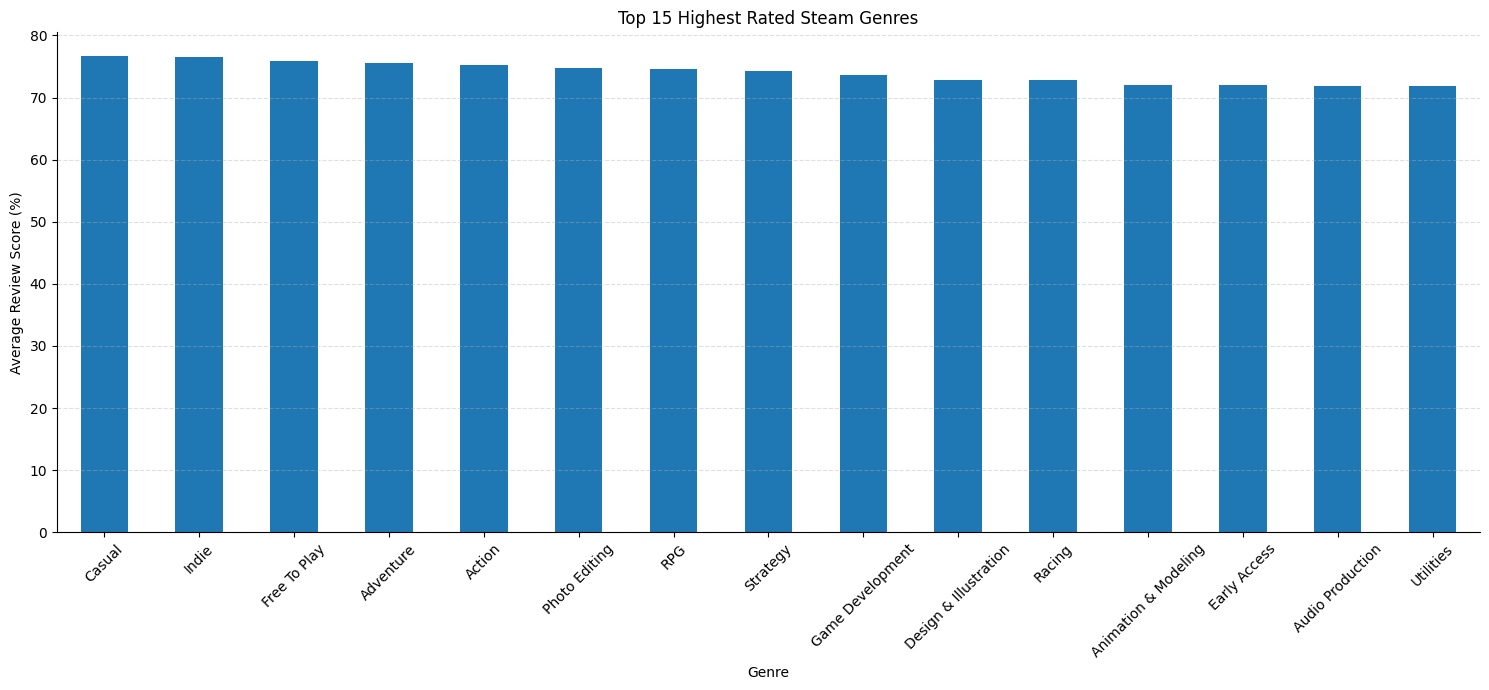

In [16]:
fig, ax = plt.subplots(figsize=(15,7))

top_reviewed.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 15 Highest Rated Steam Genres")
ax.set_xlabel("Genre")
ax.set_ylabel("Average Review Score (%)")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/highest_rated_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Genre Analysis - Question 3

In [17]:
engagement = genres.copy()

In [18]:
engagement = engagement[
    (engagement["Average playtime forever"] > 0) &
    (engagement["Genres"].notna())
]

In [19]:
genre_counts = engagement["Genres"].value_counts()

valid = genre_counts[genre_counts >= 100].index

engagement = engagement[
    engagement["Genres"].isin(valid)
]

In [20]:
genre_playtime = (
    engagement
    .groupby("Genres")["Average playtime forever"]
    .mean()
    .sort_values(ascending=False)
)

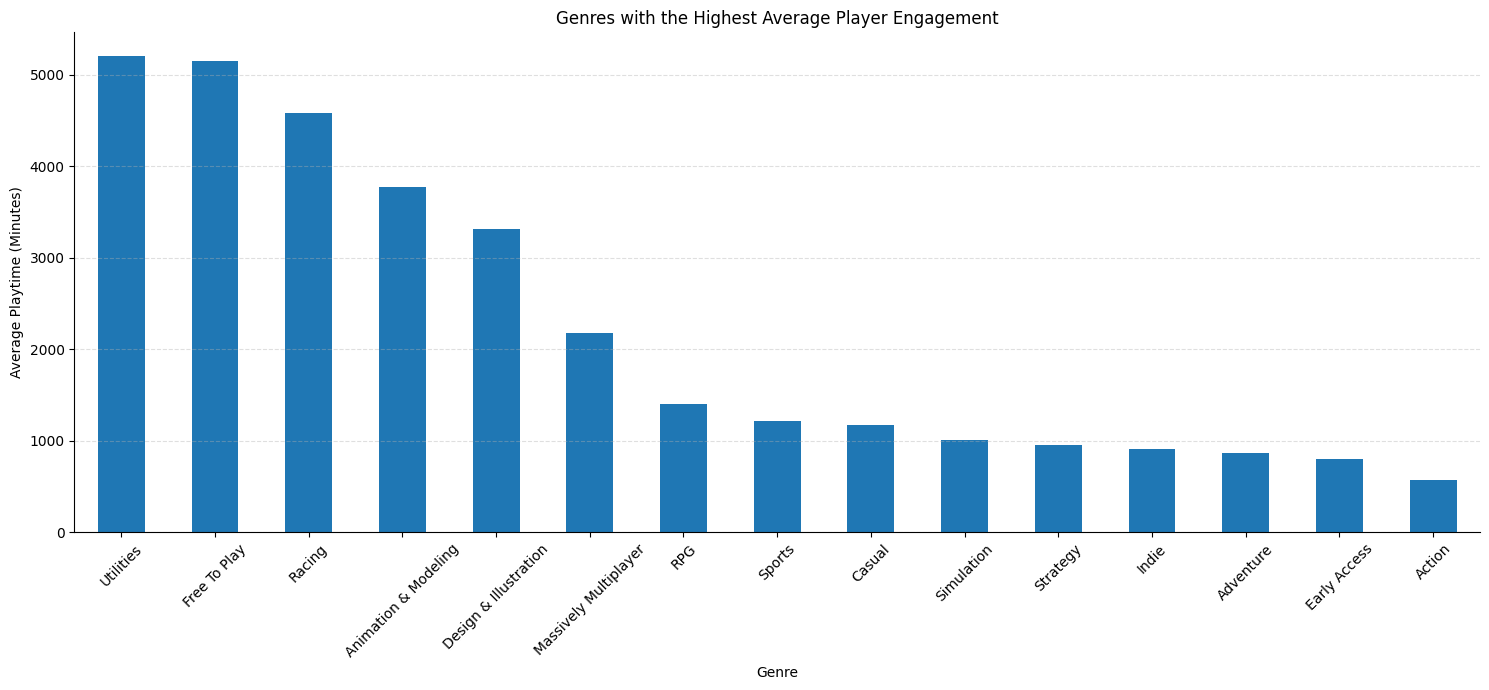

In [21]:
fig, ax = plt.subplots(figsize=(15,7))

genre_playtime.head(15).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Genres with the Highest Average Player Engagement")
ax.set_xlabel("Genre")
ax.set_ylabel("Average Playtime (Minutes)")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/highest_player_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Genre Analysis - Question 4

In [22]:
genre_count = genres["Genres"].value_counts()

genre_rating = (
    genres
    .groupby("Genres")["Review Score %"]
    .mean()
)

comparison = pd.DataFrame({
    "Game Count": genre_count,
    "Average Review": genre_rating
})

In [23]:
comparison = comparison[
    comparison["Game Count"] >= 100
]

In [24]:
comparison.sort_values(
    by="Game Count",
    ascending=False,
    inplace=True
)

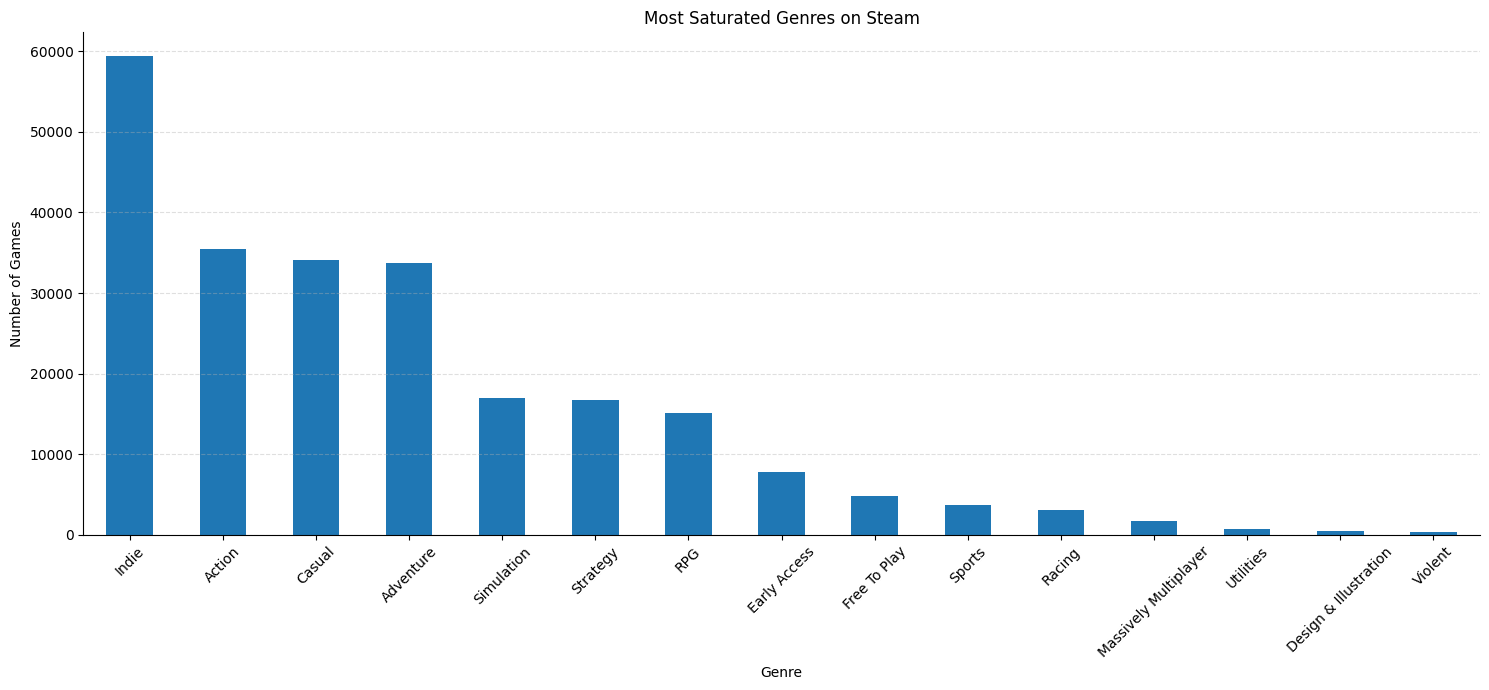

In [25]:
fig, ax = plt.subplots(figsize=(15,7))

comparison["Game Count"].head(15).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Most Saturated Genres on Steam")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Games")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Genre Analysis/most_saturated_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price Analysis - Question 1

In [26]:
price_reviews = steam[
    steam["Total Reviews"] > 0
].copy()

In [27]:
correlation = price_reviews["Price"].corr(
    price_reviews["Review Score %"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: -0.039


In [28]:
sample = price_reviews.sample(
    n=10000,
    random_state=42
)

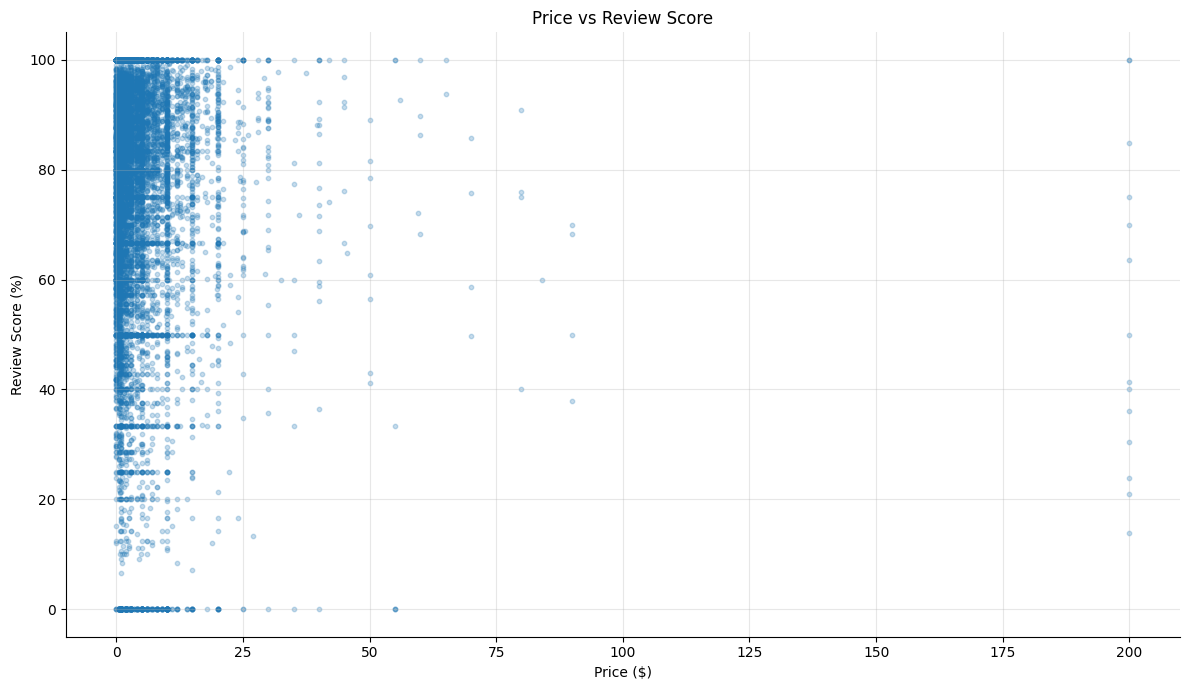

In [29]:
fig, ax = plt.subplots(figsize=(12,7))

ax.scatter(
    sample["Price"],
    sample["Review Score %"],
    alpha=0.25,
    s=10
)

ax.set_title("Price vs Review Score")

ax.set_xlabel("Price ($)")

ax.set_ylabel("Review Score (%)")

ax.grid(alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    "../Images/Pricing Analysis/price_vs_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price Analysis - Question 2

In [30]:
price_counts = (
    steam["Price Category"]
    .value_counts()
)

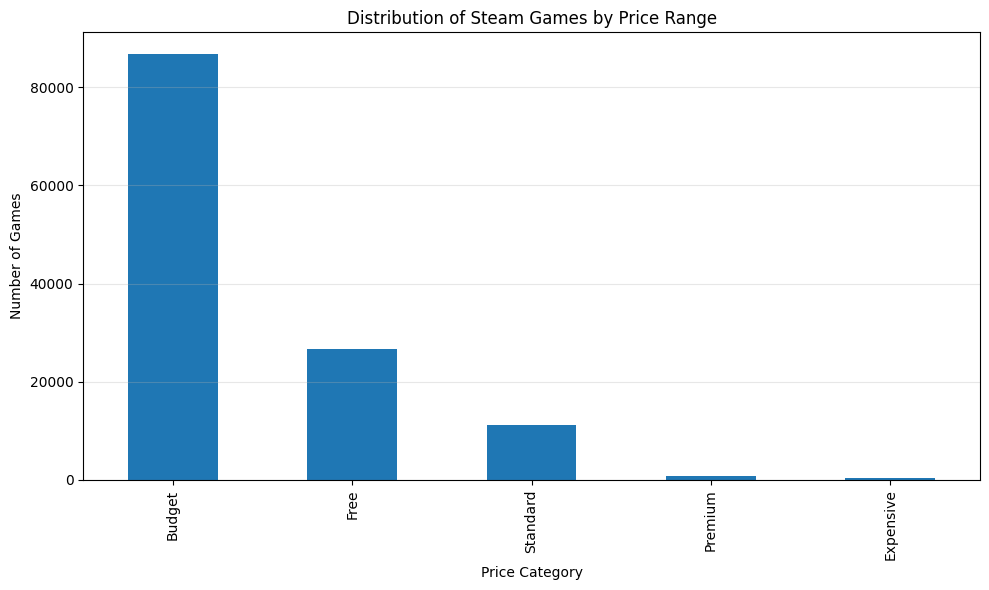

In [31]:
fig, ax = plt.subplots(figsize=(10,6))

price_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribution of Steam Games by Price Range")
ax.set_xlabel("Price Category")
ax.set_ylabel("Number of Games")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    "../Images/Pricing Analysis/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price Analysis - Question 3

In [32]:
comparison = steam.copy()

comparison["Game Type"] = np.where(
    comparison["Price"] == 0,
    "Free",
    "Paid"
)

In [33]:
game_type_reviews = (
    comparison[
        comparison["Total Reviews"] > 0
    ]
    .groupby("Game Type")["Review Score %"]
    .mean()
)

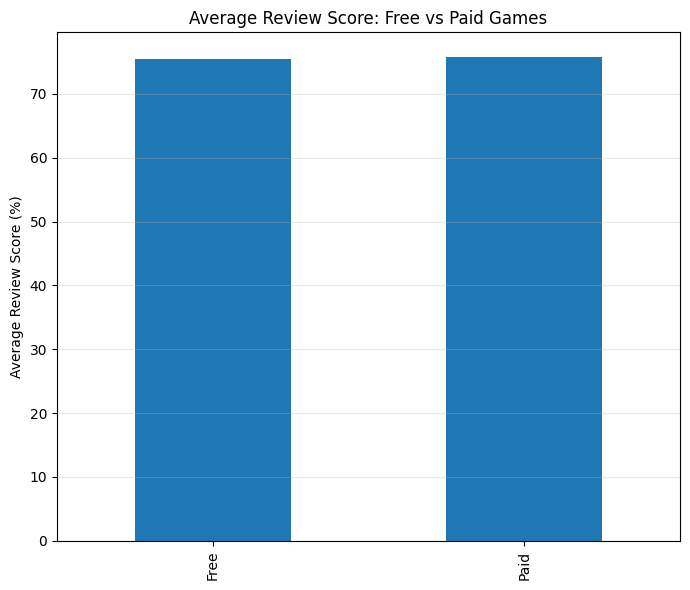

In [34]:
fig, ax = plt.subplots(figsize=(7,6))

game_type_reviews.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Average Review Score: Free vs Paid Games")
ax.set_ylabel("Average Review Score (%)")
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig.savefig(
    "../Images/Pricing Analysis/free_vs_paid_reviews.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Developer Analysis - Question 1

In [52]:
developers = steam.copy()

developers["Developers"] = (
    developers["Developers"]
    .str.split(",")
)

developers = developers.explode("Developers")

developers["Developers"] = (
    developers["Developers"]
    .str.strip()
)

bad_names = [
    "Inc.",
    "Inc",
    "LLC",
    "Ltd.",
    "Ltd",
    "LTD.",
    "LTD",
    "Co.",
    "Corp.",
    "Corporation"
]

developers = developers[
    ~developers["Developers"].isin(bad_names)
]

In [53]:
developers = developers[
    developers["Developers"].notna()
]

In [54]:
developer_counts = (
    developers["Developers"]
    .value_counts()
    .head(15)
)

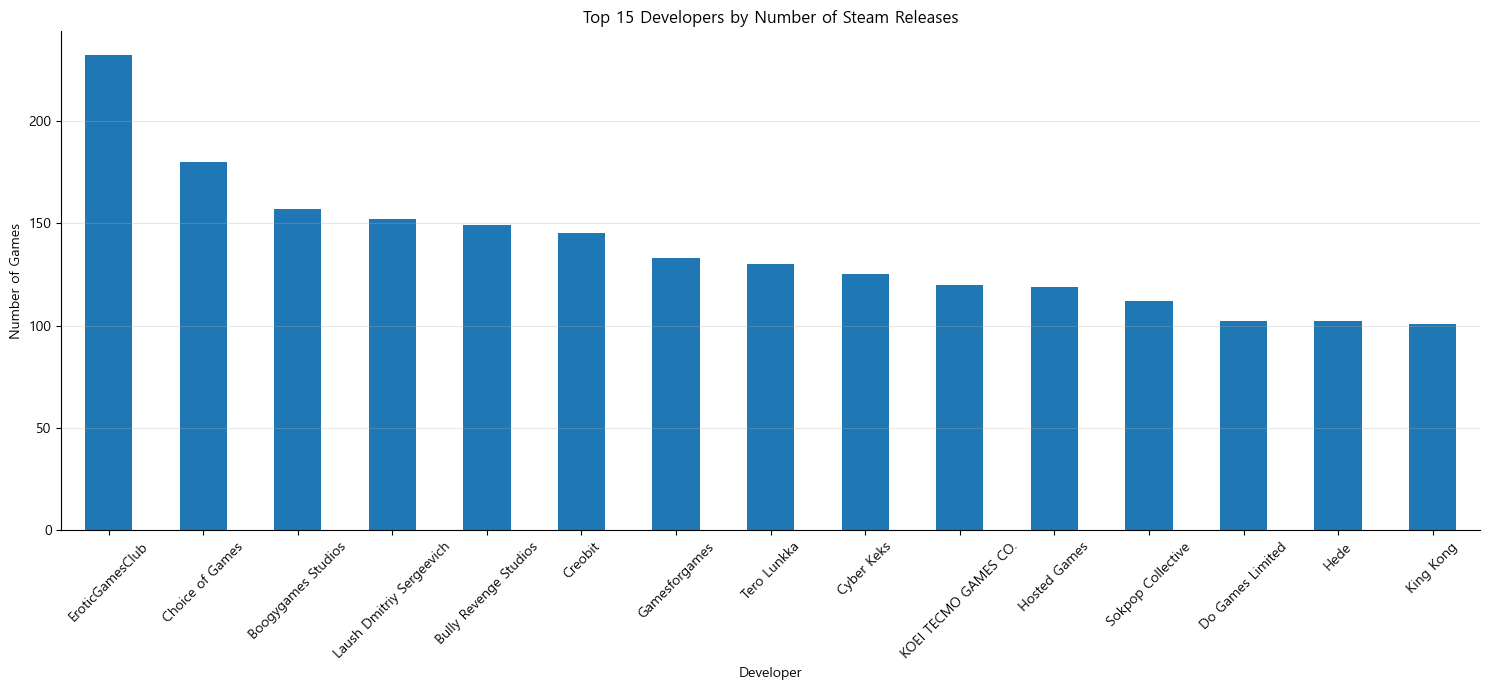

In [55]:
fig, ax = plt.subplots(figsize=(15,7))

developer_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 15 Developers by Number of Steam Releases")

ax.set_xlabel("Developer")

ax.set_ylabel("Number of Games")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Developer Analysis/top_developers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Developer Analysis - Question 2

In [56]:
publishers = steam.copy()

publishers["Publishers"] = (
    publishers["Publishers"]
    .str.split(",")
)

publishers = publishers.explode("Publishers")

publishers["Publishers"] = (
    publishers["Publishers"]
    .str.strip()
)
bad_names = [
    "Inc.",
    "Inc",
    "LLC",
    "Ltd.",
    "Ltd",
    "LTD.",
    "LTD",
    "Co.",
    "Corp.",
    "Corporation"
]

publishers = publishers[
    ~publishers["Publishers"].isin(bad_names)
]

In [57]:
publishers = publishers[
    publishers["Publishers"].notna()
]

In [58]:
publisher_counts = (
    publishers["Publishers"]
    .value_counts()
    .head(15)
)

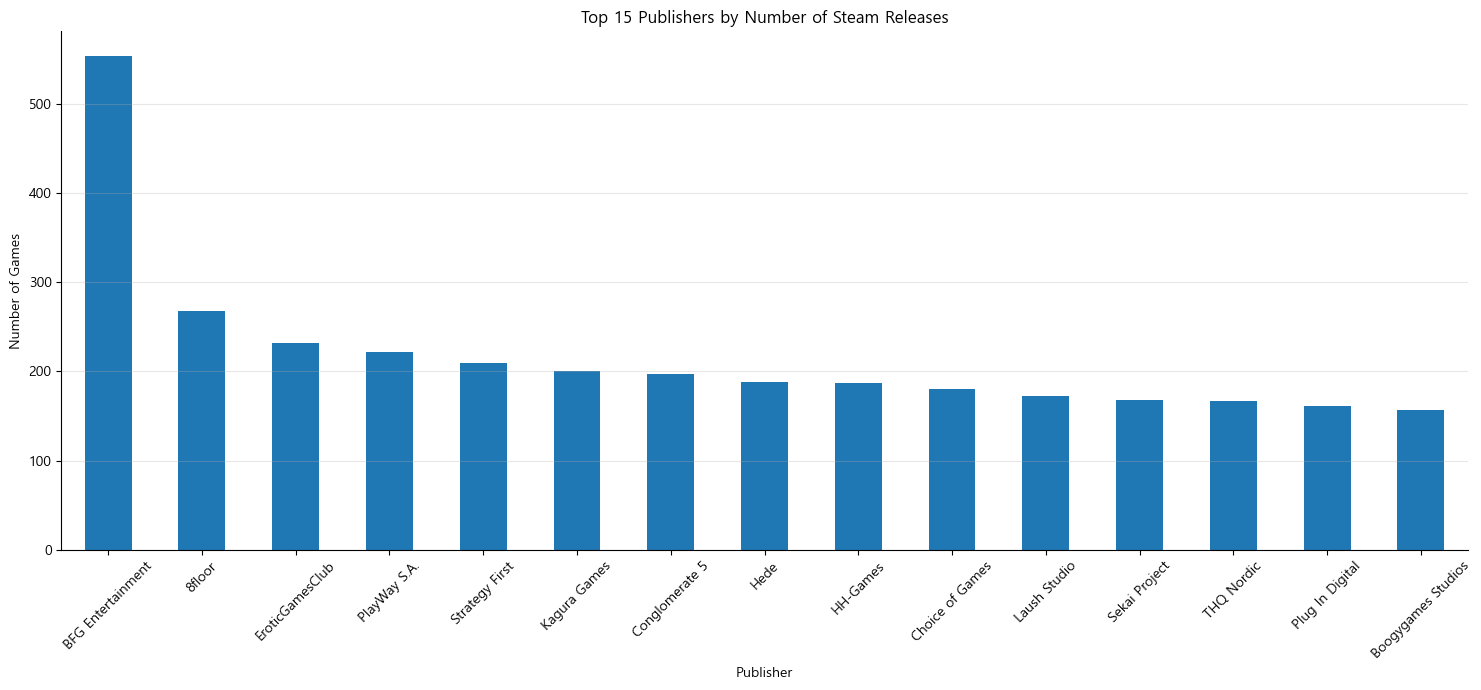

In [59]:
fig, ax = plt.subplots(figsize=(15,7))

publisher_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 15 Publishers by Number of Steam Releases")

ax.set_xlabel("Publisher")

ax.set_ylabel("Number of Games")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Developer Analysis/top_publishers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Developer Analysis - Question 3

In [72]:
developer_stats = developers.copy()

In [73]:
developer_stats = developer_stats[
    developer_stats["Total Reviews"] > 0
]

In [74]:
developer_summary = (
    developer_stats
    .groupby("Developers")
    .agg(
        Games=("Name", "count"),
        Average_Review=("Review Score %", "mean"),
        Total_Reviews=("Total Reviews", "sum")
    )
)

In [76]:
developer_summary = developer_summary[
    (developer_summary["Games"] >= 5) &
    (developer_summary["Total_Reviews"] >= 1000)
]

In [77]:
top_developers = (
    developer_summary
    .sort_values("Average_Review", ascending=False)
    .head(15)
)

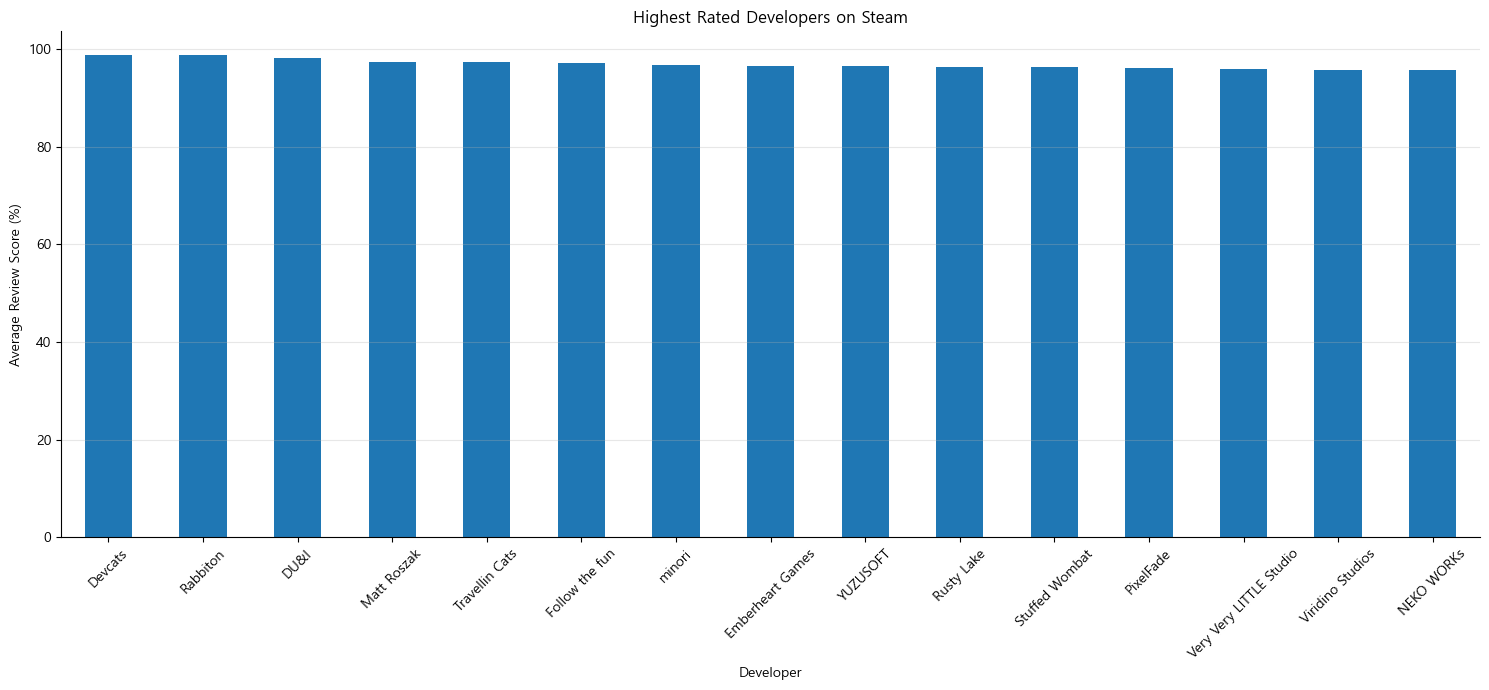

In [78]:
fig, ax = plt.subplots(figsize=(15,7))

top_developers["Average_Review"].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Highest Rated Developers on Steam")
ax.set_xlabel("Developer")
ax.set_ylabel("Average Review Score (%)")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "../Images/Developer Analysis/highest_rated_developers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()